In [1]:
import numpy as np
import math
from IPython.display import SVG, display

In [2]:
ket0 = np.array([1,0], dtype = complex)
ket1 = np.array([0,1], dtype = complex)

In [3]:
print(ket0)
print(ket1)

[1.+0.j 0.+0.j]
[0.+0.j 1.+0.j]


In [4]:
psi = (ket0 + ket1) / np.sqrt(2)

print(psi)

[0.70710678+0.j 0.70710678+0.j]


In [5]:
probabilities = np.abs(psi)**2

print(probabilities)
print(probabilities.sum())

[0.5 0.5]
0.9999999999999998


In [6]:
def validate_state(mat):

    prob = np.abs(mat)**2

    if math.isclose(prob.sum(), 1.0, abs_tol=1e-3):      
        return True

    return False
    

In [7]:
# I = np.array([
#     [1, 0],
#     [0, 1]
# ], dtype=complex)

# X = np.array([
#     [0, 1],
#     [1, 0]
# ], dtype=complex)

# Y = np.array([
#     [0, -1j],
#     [1j, 0]
# ], dtype=complex)

# Z = np.array([
#         [1, 0],
#         [0, -1]
#     ], dtype=complex)

# H = (1 / np.sqrt(2)) * np.array([
#     [1, 1],
#     [1, -1]
# ], dtype=complex)

gates = {
    "I": np.array([
        [1, 0],
        [0, 1]
    ], dtype=complex),

    "X": np.array([
        [0, 1],
        [1, 0]
    ], dtype=complex),

    "Y": np.array([
        [0, -1j],
        [1j, 0]
    ], dtype=complex),

    "Z": np.array([
        [1, 0],
        [0, -1]
    ], dtype=complex),

    "H": (1 / np.sqrt(2)) * np.array([
        [1, 1],
        [1, -1]
    ], dtype=complex),

}

In [8]:
def is_unitary(matrix):

    if matrix.ndim != 2:
        return False

    if matrix.shape[0] != matrix.shape[1]:
        return False

    con = matrix.conj().T

    identity = np.eye(matrix.shape[0], dtype=complex)
    return np.allclose(con @ matrix, identity)

In [9]:
def apply_gate(gate, state):

    if not validate_state(state):
        raise ValueError("State not normalized!!!")

    if gate not in gates:
        raise ValueError(f"Unknown gate: {gate}")

    if not is_unitary(gates[gate]):
        raise ValueError("Gate must be unitary!!!")

    if gates[gate].shape[0] != state.shape[0]:
        raise ValueError("Gate and state dimensions do not match!!!")

    target = gates[gate] @ state

    if not validate_state(target):
        raise ValueError("Target is not unitary!!!")

    return target

In [10]:
def measure(state):

    if not validate_state(state):
        raise ValueError("Invalid State!!!")

    probs = np.abs(state)**2

    target = np.random.choice(len(state), p=probs)

    return target

In [11]:
ket00 = np.array([1, 0, 0, 0], dtype=complex)

ket01 = np.array([0, 1, 0, 0], dtype=complex)

ket10 = np.array([0, 0, 1, 0], dtype=complex)

ket11 = np.array([0, 0, 0, 1], dtype=complex)

In [12]:
def tensor_product(a,b):

    return np.kron(a,b)

In [13]:
def index_to_basis_state(index, num_qubits):
    return format(index, f"0{num_qubits}b")

In [14]:
bell_states = {
    "phi_plus": (ket00 + ket11) / np.sqrt(2),

    "phi_minus": (ket00 - ket11) / np.sqrt(2),

    "psi_plus": (ket01 + ket10) / np.sqrt(2),

    "psi_minus": (ket01 - ket10) / np.sqrt(2)
}

In [15]:
for name, state in bell_states.items():
    print(name)
    print(state)
    print()

phi_plus
[0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]

phi_minus
[ 0.70710678+0.j  0.        +0.j  0.        +0.j -0.70710678+0.j]

psi_plus
[0.        +0.j 0.70710678+0.j 0.70710678+0.j 0.        +0.j]

psi_minus
[ 0.        +0.j  0.70710678+0.j -0.70710678+0.j  0.        +0.j]



In [16]:
def inner_product(a,b):
    return np.vdot(a,b)

In [17]:
def is_separable(state):

    if not validate_state(state):
        raise ValueError("State must be normalized!!!")

    if state.shape != (4,):
        raise ValueError("State must be a two bit state!!!")

    matrix = state.reshape(2,2)

    det = np.linalg.det(matrix)

    return np.isclose(det, 0.0)

In [18]:
def is_entangled(state):
    return not is_separable(state)

In [19]:
def get_num_qubits(state):

    dimensions = len(state)

    num_qubits = int(np.log2(dimensions))

    if 2**num_qubits != dimensions:
        raise ValueError("State dimensions must be a power of 2.")

    return num_qubits

In [20]:
def run_measurement_experiment(state, shots=10000):

    if shots<=0:
        raise ValueError("Shots must be a positive integer!!!")

    num_qubits = get_num_qubits(state)

    dimensions = 2**num_qubits 

    counts = {
        index: 0
        for index in range(dimensions)
    }

    for _ in range(shots):
        result = measure(state)
        counts[result] += 1

    for index, count in counts.items():

        basis = index_to_basis_state(index, 2)

        print(f"{basis} → {count}")

    return counts

In [21]:
def build_single_qubit_operator(gate_name, target, num):

    if gate_name not in gates:
        raise ValueError("Invalid Gates!!!")

    if num<1:
        raise ValueError("Insufficient number of qubits!!!")

    if target < 0 or target >= num:
        raise ValueError("Target qubit index out of range.")

    gate = gates[gate_name]

    if gate.shape != (2, 2):
        raise ValueError("Gate must be a single-qubit 2x2 gate.")

    operator = np.array([[1]], dtype=complex)

    for qubit in range(num):
        if qubit == target:
            operator = np.kron(operator,gate)

        else:
            operator = np.kron(operator, gates["I"])

    return operator

    

In [22]:
def apply_single_qubit_gate(gate, state, target, num):

    expected_dimensions = 2**num

    if state.shape != (expected_dimensions,):
        raise ValueError(
            f"Expected {expected_dimensions}-dimensional "
            f"state for {num} qubits."
        )

    if not validate_state(state):
        raise ValueError("State must be normalized!!!")

    operator = build_single_qubit_operator(gate, target, num)

    if not is_unitary(operator):
        raise ValueError("Constructed Operator is not Unitary!!!")

    result = operator @ state

    if not validate_state(result):
        raise ValueError("Resulting state is not normalized!!!")

    return result



In [23]:
def build_controlled_gate(gate_name):

    if gate_name not in gates:
        raise ValueError("Invalid Gates!!!")

    gate = gates[gate_name]

    if gate.shape != (2,2):
        raise ValueError("Not a 2x2 matrix!!!")

    P0 = np.outer(ket0, ket0.conj())
    P1 = np.outer(ket1, ket1.conj())

    controlled = np.kron(P0,gates["I"]) + np.kron(P1, gate)

    return controlled

In [24]:
def build_controlled_operator(gate_name, control, target, num_qubits):

    if gate_name not in gates:
        raise ValueError("Invalid Gate!!!")

    if num_qubits<2:
        raise ValueError("Controlled gates require atleast 2 qubits!!!")

    if control<0 or control>=num_qubits:
        raise ValueError("Control qubit index out of range!!!")

    if target<0 or target>=num_qubits:
        raise ValueError("Target qubit index out of range!!!")

    if control == target:
        raise ValueError("Control and Target must be different!!!")

    gate = gates[gate_name]

    if gate.shape != (2,2):
        raise ValueError("Controlled gates must be 2x2 gates!!!")

    dimension = 2**num_qubits

    operator = np.zeros((dimension,dimension),dtype = complex)

    for input_index in range(dimension):

        bits = list(format(input_index, f"0{num_qubits}b"))

        if bits[control] == "0":

            operator[input_index,input_index] = 1

        else:

            target_bit = int(bits[target])

            for output_target_bit in [0,1]:

                amplitude = gate[output_target_bit, target_bit]

                if np.isclose(amplitude,0):
                    continue

                output_bits = bits.copy()

                output_bits[target] = str(output_target_bit)

                output_index = int("".join(output_bits),2)

                operator[output_index, input_index] = amplitude

    return operator

In [25]:
def apply_controlled_gate(gate_name, state, control, target, num_qubits):

    dimensions = 2**num_qubits

    if state.shape != (dimensions,):
        raise ValueError("State dimensions does not match number of qubits!!!")

    if not validate_state(state):
        raise ValueError("State must be normalized!!!")

    operator = build_controlled_operator(gate_name, control, target, num_qubits)

    result = operator @ state

    if not validate_state(result):
        raise ValueError("Resulting state is not normalized!!!")

    return result

In [26]:
operations = [
    {
        "type": "single",
        "gate": "H",
        "target": 0
    },
    {
        "type": "controlled",
        "gate": "X",
        "control": 0,
        "target": 1
    }
]

In [27]:
def execute_operations(operations, initial_state, num_qubits):

    state = initial_state.copy()

    for operation in operations:

        if operation["type"] == "single":

            state = apply_single_qubit_gate(operation["gate"], state, operation["target"], num_qubits)

        elif operation["type"] == "controlled":

            state = apply_controlled_gate(operation["gate"], state, operation["control"], operation["target"], num_qubits)

        else:

            raise ValueError(
                f"Unknown operation type: "
                f"{operation['type']}"
            )

    return state

In [28]:
def circuit_to_svg(circuit):

    num_qubits = circuit.num_qubits
    operations = circuit.operations

    gate_spacing = 100
    left_margin = 80
    top_margin = 50
    qubit_spacing = 70

    width = (
        left_margin
        + (len(operations) + 1) * gate_spacing
        + 50
    )

    height = (
        top_margin
        + num_qubits * qubit_spacing
        + 50
    )

    svg = [
        f'<svg xmlns="http://www.w3.org/2000/svg" '
        f'width="{width}" height="{height}" '
        f'viewBox="0 0 {width} {height}">'
    ]

    for qubit in range(num_qubits):

        y = top_margin + qubit * qubit_spacing

        svg.append(
            f'<line '
            f'x1="{left_margin}" '
            f'y1="{y}" '
            f'x2="{width - 30}" '
            f'y2="{y}" '
            f'stroke="black" '
            f'stroke-width="2"/>'
        )

        svg.append(
            f'<text '
            f'x="20" '
            f'y="{y + 5}" '
            f'font-size="18">'
            f'q{qubit}'
            f'</text>'
        )


    for operation_index, operation in enumerate(operations):

        x = (
            left_margin
            + (operation_index + 1) * gate_spacing
        )


        if operation["type"] == "single":

            target = operation["target"]
            gate_name = operation["gate"]

            target_y = (
                top_margin
                + target * qubit_spacing
            )

            svg.append(
                f'<rect '
                f'x="{x - 25}" '
                f'y="{target_y - 20}" '
                f'width="50" '
                f'height="40" '
                f'fill="white" '
                f'stroke="black" '
                f'stroke-width="2"/>'
            )

            svg.append(
                f'<text '
                f'x="{x}" '
                f'y="{target_y + 6}" '
                f'text-anchor="middle" '
                f'font-size="18">'
                f'{gate_name}'
                f'</text>'
            )


        elif operation["type"] == "controlled":

            control = operation["control"]
            target = operation["target"]
            gate_name = operation["gate"]

            control_y = (
                top_margin
                + control * qubit_spacing
            )

            target_y = (
                top_margin
                + target * qubit_spacing
            )

            svg.append(
                f'<line '
                f'x1="{x}" '
                f'y1="{control_y}" '
                f'x2="{x}" '
                f'y2="{target_y}" '
                f'stroke="black" '
                f'stroke-width="2"/>'
            )

            svg.append(
                f'<circle '
                f'cx="{x}" '
                f'cy="{control_y}" '
                f'r="8" '
                f'fill="black"/>'
            )

            if gate_name == "X":

                radius = 14

                svg.append(
                    f'<circle '
                    f'cx="{x}" '
                    f'cy="{target_y}" '
                    f'r="{radius}" '
                    f'fill="white" '
                    f'stroke="black" '
                    f'stroke-width="2"/>'
                )

                svg.append(
                    f'<line '
                    f'x1="{x - 10}" '
                    f'y1="{target_y - 10}" '
                    f'x2="{x + 10}" '
                    f'y2="{target_y + 10}" '
                    f'stroke="black" '
                    f'stroke-width="2"/>'
                )

                svg.append(
                    f'<line '
                    f'x1="{x + 10}" '
                    f'y1="{target_y - 10}" '
                    f'x2="{x - 10}" '
                    f'y2="{target_y + 10}" '
                    f'stroke="black" '
                    f'stroke-width="2"/>'
                )

            else:

                svg.append(
                    f'<rect '
                    f'x="{x - 25}" '
                    f'y="{target_y - 20}" '
                    f'width="50" '
                    f'height="40" '
                    f'fill="white" '
                    f'stroke="black" '
                    f'stroke-width="2"/>'
                )

                svg.append(
                    f'<text '
                    f'x="{x}" '
                    f'y="{target_y + 6}" '
                    f'text-anchor="middle" '
                    f'font-size="18">'
                    f'{gate_name}'
                    f'</text>'
                )

        else:

            raise ValueError(
                f"Unknown operation type: "
                f"{operation['type']}"
            )

    svg.append("</svg>")

    return "\n".join(svg)

In [29]:
class QuantumCircuit:

    def __init__(self,num_qubits):

        if num_qubits<1:
            raise ValueError("Circuit must contain atleast 1 qubit!!!")

        self.num_qubits = num_qubits

        self.classical_bits = {}

        self.operations = []

        self.initial_state = np.zeros(2**num_qubits, dtype = complex)

        self.initial_state[0] = 1.0


    def add_gate(self, gate_name, target):

        if gate_name not in gates:

            raise ValueError(f"Unknown gate: {gate_name}")


        if target<0 or target>=self.num_qubits:

            raise ValueError("Target qubit index out of range!!!")


        self.operations.append({
            "type": "single",
            "gate": gate_name,
            "target": target
        })


    def h(self, target):
        self.add_gate("H", target)

    def x(self, target):
        self.add_gate("X", target)

    def y(self, target):
        self.add_gate("Y", target)

    def z(self, target):
        self.add_gate("Z", target)

        

    def controlled(self, gate_name, control, target):

        if gate_name not in gates:
            raise ValueError(f"Unknown gate: {gate_name}")


        if control<0 or control>=self.num_qubits:
            raise ValueError("Control qubit index out of range!!!")


        if target<0 or target>=self.num_qubits:
            raise ValueError("Target qubit index out of range!!!")

        if control == target:
            raise ValueError("Control and Target must be different!!!")


        self.operations.append({
            "type": "controlled",
            "gate": gate_name,
            "control": control,
            "target": target
        })



    def run(self):

        return execute_operations(self.operations, self.initial_state, self.num_qubits)


    def measure(self, shots = 10000):

        state = self.run()

        return run_measurement_experiment(state, shots)


    def draw_svg(self):

        return SVG(circuit_to_svg(self))


    def measure_qubit(self, qubit, classical_bit):

        if qubit<0 or qubit >= self.num_qubits:
            raise ValueError("Qubit index out of range!!!")

        if classical_bit<0:
            raise ValueError("Classical bit index cannot be 0!!!")

        self.operations.append({
            "type": "measurement",
            "qubit": qubit,
            
        })
    

        

In [30]:
circuit = QuantumCircuit(2)

circuit.x(0)
circuit.controlled("Z", 0, 1)
circuit.h(1)

state = circuit.run()

In [31]:
state


array([0.        +0.j, 0.        +0.j, 0.70710678+0.j, 0.70710678+0.j])

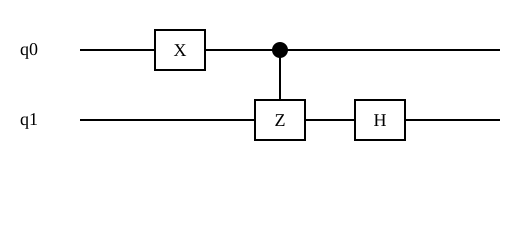

In [32]:
circuit.draw_svg()